In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick

In [ ]:
df = pd.read_csv("recap_v2.csv")
df

,language,setting,agent_critical,agent_minor,agent_correct,user_critical,user_minor,user_correct
0,Chinese,L2 Interaction,39.88%,18.52%,41.59%,23.52%,36.19%,40.29%
1,Chinese,L2 Domain,45.70%,19.90%,34.40%,23.12%,34.16%,42.73%
2,Filipino,L2 Interaction,39.80%,21.15%,39.05%,28.05%,34.32%,37.63%
3,Filipino,L2 Domain,47.98%,19.66%,32.35%,29.34%,34.62%,36.05%
4,Indonesian,L2 Interaction,42.85%,20.08%,37.07%,22.23%,35.94%,41.83%
5,Indonesian,L2 Domain,46.08%,20.64%,33.29%,24.15%,32.25%,43.60%
6,Thai,L2 Interaction,47.70%,19.00%,33.30%,24.25%,35.05%,40.71%
7,Thai,L2 Domain,52.06%,17.91%,30.03%,30.84%,25.77%,43.39%
8,Vietnamese,L2 Interaction,41.13%,24.46%,34.40%,23.98%,34.94%,41.08%
9,Vietnamese,L2 Domain,41.54%,21.98%,36.47%,23.59%,31.92%,44.49%


In [22]:
# Use existing df
languages = ["English", "Filipino", "Vietnamese", "Indonesian", "Thai",  "Chinese"]
lang_map = {
    "English": "EN",
    "Vietnamese": "VI",
    "Thai": "TH",
    "Indonesian": "ID",
    "Chinese": "ZH",
    "Filipino": "TL"
}

model_map = {
    "qwen3-235b-a22b-inst": "Qwen3-235B Inst",
    "gpt-5-mini": "GPT-5 Mini",
}

# Use existing df and languages
metrics = ["pass@1", "rho^3"]

angles = np.linspace(0, 2 * np.pi, len(languages), endpoint=False).tolist()
angles += angles[:1]

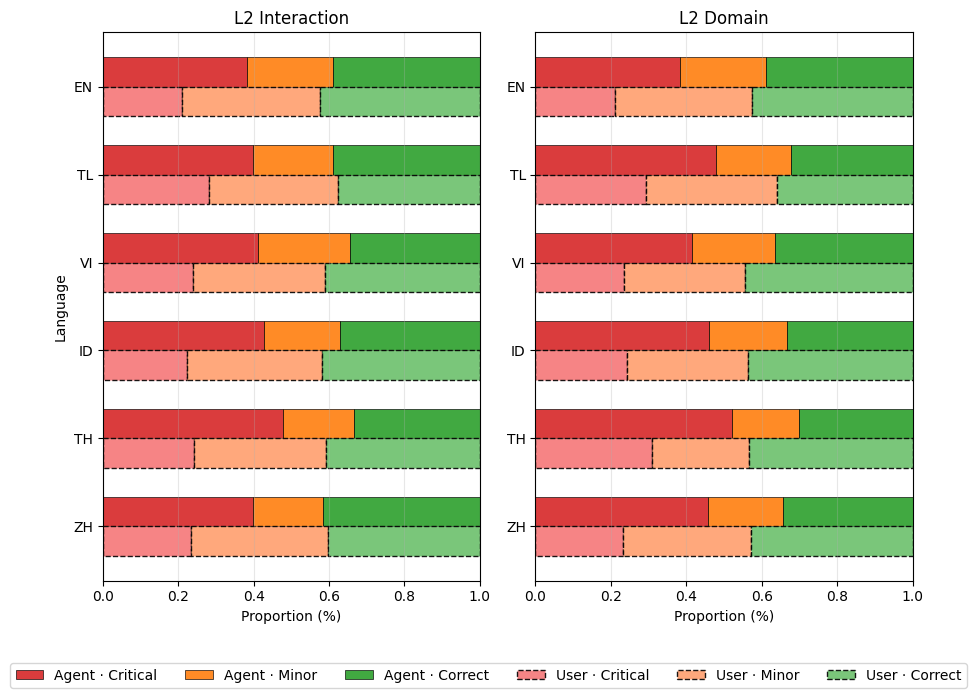

In [23]:
# Horizontal stacked bars with who (Agent/User) as style, split by setting
required_cols = [
    "language", "setting",
    "agent_critical", "agent_minor", "agent_correct",
    "user_critical", "user_minor", "user_correct"
]

plot_df = df.loc[:, required_cols].copy()

# Convert percentage strings to float
for col in required_cols[2:]:
    plot_df[col] = pd.to_numeric(
        plot_df[col].astype(str).str.replace("%", "", regex=False),
        errors="coerce"
    )

# Scale to [0,1] if needed
if plot_df[required_cols[2:]].max().max() > 1:
    plot_df[required_cols[2:]] = plot_df[required_cols[2:]] / 100.0

agent_cols = ["agent_critical", "agent_minor", "agent_correct"]
user_cols = ["user_critical", "user_minor", "user_correct"]

# Re-normalize per row
plot_df[agent_cols] = plot_df[agent_cols].div(plot_df[agent_cols].sum(axis=1), axis=0)
plot_df[user_cols] = plot_df[user_cols].div(plot_df[user_cols].sum(axis=1), axis=0)

settings = plot_df["setting"].unique().tolist()

if "languages" in globals():
    lang_order = [lang for lang in languages if lang in plot_df["language"].unique()]
    lang_order += [lang for lang in plot_df["language"].unique() if lang not in lang_order]
else:
    lang_order = plot_df["language"].unique().tolist()

colors = {
    "critical": "#d62728",
    "minor": "#ff7f0e",
    "correct": "#2ca02c"
}
pale_colors = {
    "critical": "#f67778",
    "minor": "#ff9f6e",
    "correct": "#6cc06c"
}

# 1.5x wider per axis: 4.5 instead of 3.0 width per setting
fig, axes = plt.subplots(1, len(settings), figsize=(4.5 * len(settings), 7), sharex=True, squeeze=False)
axes = axes[0]

who_list = ["agent", "user"]
who_palette = {"agent": colors, "user": pale_colors}

# Differentiate Agent/User without hatching
who_style = {
    "agent": {"edgecolor": "black", "linewidth": 0.5, "linestyle": "-"},
    "user": {"edgecolor": "black", "linewidth": 1.0, "linestyle": "--"},
}

bar_h = 0.75 / len(who_list)
offsets = (np.arange(len(who_list)) - (len(who_list) - 1) / 2) * bar_h

group_gap = 0.12
y_centers = np.arange(len(lang_order)) * (1 + group_gap)

for ax, setting in zip(axes, settings):
    sub = plot_df[plot_df["setting"] == setting].copy()
    sub["language"] = pd.Categorical(sub["language"], categories=lang_order, ordered=True)
    sub = sub.sort_values("language").set_index("language").reindex(lang_order)

    for i, who in enumerate(who_list):
        y = y_centers + offsets[i]
        left = np.zeros(len(lang_order))

        for part in ["critical", "minor", "correct"]:
            vals = sub[f"{who}_{part}"].to_numpy()
            ax.barh(
                y, vals, bar_h, left=left,
                color=who_palette[who][part], alpha=0.9,
                edgecolor=who_style[who]["edgecolor"],
                linewidth=who_style[who]["linewidth"],
                linestyle=who_style[who]["linestyle"],
                label=f"{who.capitalize()} · {part.capitalize()}"
            )
            left += vals

    ax.set_title(f"{setting}")
    ax.set_xlim(0, 1.0)
    ax.set_yticks(y_centers)
    ax.set_yticklabels([lang_map.get(lang, lang) for lang in lang_order])
    ax.invert_yaxis()  # first language appears at top
    ax.grid(axis="x", alpha=0.3)

axes[0].set_ylabel("Language")
for ax in axes:
    ax.set_xlabel("Proportion (%)")

# Deduplicated legend
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
fig.legend(
    uniq.values(),
    uniq.keys(),
    ncol=6,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


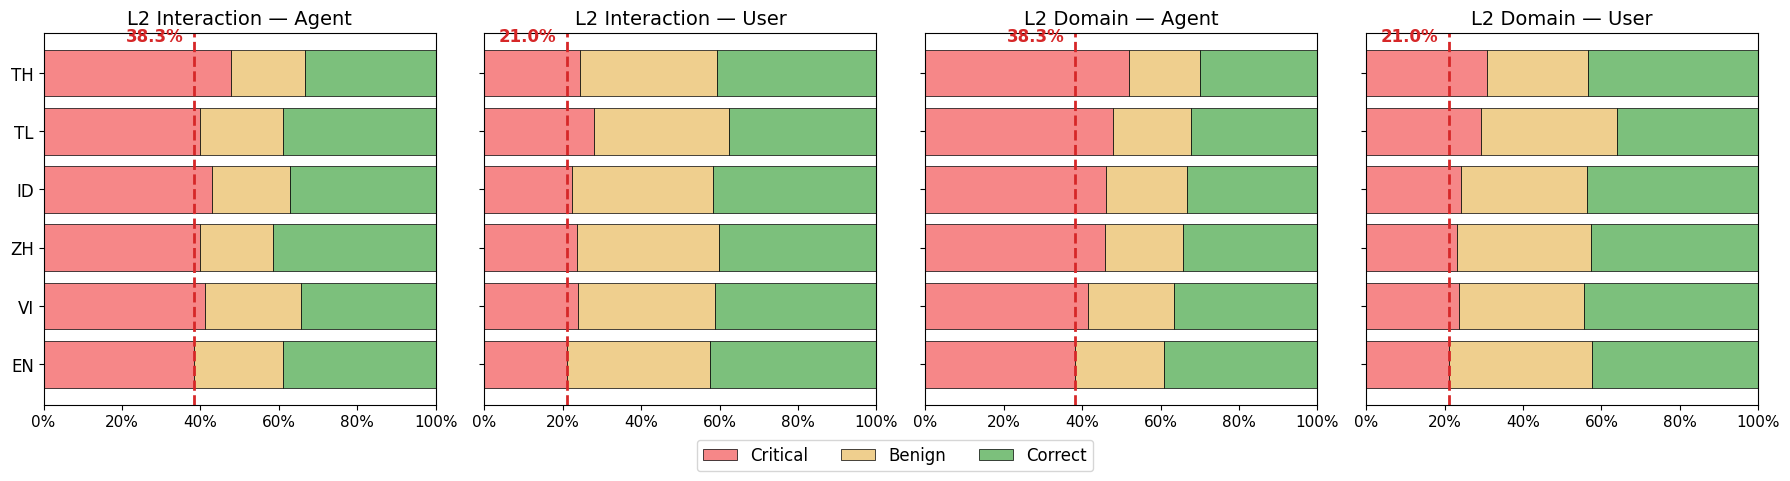

In [ ]:
# Horizontal stacked bars for both settings, split into Agent/User (4 subplots, 1 row)
required_cols = [
    "language", "setting",
    "agent_critical", "agent_minor", "agent_correct",
    "user_critical", "user_minor", "user_correct"
]

plot_df = df.loc[:, required_cols].copy()

# Convert percentage strings to float
for col in required_cols[2:]:
    plot_df[col] = pd.to_numeric(
        plot_df[col].astype(str).str.replace("%", "", regex=False),
        errors="coerce"
    )

# Scale to [0,1] if needed
if plot_df[required_cols[2:]].max().max() > 1:
    plot_df[required_cols[2:]] = plot_df[required_cols[2:]] / 100.0

agent_cols = ["agent_critical", "agent_minor", "agent_correct"]
user_cols = ["user_critical", "user_minor", "user_correct"]

# Re-normalize per row (safe divide)
agent_sum = plot_df[agent_cols].sum(axis=1).replace(0, np.nan)
user_sum = plot_df[user_cols].sum(axis=1).replace(0, np.nan)
plot_df[agent_cols] = plot_df[agent_cols].div(agent_sum, axis=0)
plot_df[user_cols] = plot_df[user_cols].div(user_sum, axis=0)

settings = ["L2 Interaction", "L2 Domain"]
who_list = ["agent", "user"]
parts = ["critical", "minor", "correct"]

# Global language order: English first, then others by L2 Domain agent_correct desc
base = plot_df[plot_df["setting"] == "L2 Domain"].copy()
if base.empty:
    base = plot_df.copy()

if "English" in base["language"].values:
    others = (
        base.loc[base["language"] != "English", ["language", "agent_correct"]]
        .sort_values("agent_correct", ascending=False)["language"]
        .tolist()
    )
    lang_order = ["English"] + others
else:
    lang_order = base.sort_values("agent_correct", ascending=False)["language"].tolist()

colors = {
    "critical": "#d62728",
    "minor": "#ff7f0e",
    "correct": "#2ca02c"
}
pale_colors = {
    "critical": "#f68788",
    "minor": "#efcf8e",
    "correct": "#7cc07c"
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
y_centers = np.arange(len(lang_order))

for i, (setting_name, who) in enumerate([(s, w) for s in settings for w in who_list]):
    ax = axes[i]
    sub = plot_df[plot_df["setting"] == setting_name].copy()
    sub["language"] = pd.Categorical(sub["language"], categories=lang_order, ordered=True)
    sub = sub.sort_values("language").set_index("language").reindex(lang_order)

    left = np.zeros(len(lang_order))
    for part in parts:
        vals = sub[f"{who}_{part}"].to_numpy()
        ax.barh(
            y_centers,
            vals,
            left=left,
            color=pale_colors[part],
            edgecolor="black",
            linewidth=0.5,
            label="Benign" if part == "minor" else part.capitalize()
        )
        left += vals

    # English reference lines for this setting + who
    if "English" in sub.index:
        ref_critical = sub.loc["English", f"{who}_critical"]
        ref_minor = sub.loc["English", f"{who}_minor"]

        if not np.isnan(ref_critical):
            ax.axvline(ref_critical, color=colors["critical"], linestyle="--", linewidth=2.0)
            ax.text(
                ref_critical - 0.1, 0.95, f"{ref_critical:.1%}",
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=12, color=colors["critical"], fontweight="bold"
            )
        # if not np.isnan(ref_minor):
        #     ax.axvline(ref_critical + ref_minor, color=colors["minor"], linestyle="--", linewidth=2.0)
        #     ax.text(
        #         ref_critical + ref_minor - 0.07, 0.96, f"{ref_minor:.1%}",
        #         transform=ax.get_xaxis_transform(),
        #         ha="center", va="bottom", fontsize=10, color=colors["minor"], fontweight="bold"
        #     )

    ax.set_title(f"{setting_name} — {who.capitalize()}", fontsize=14)
    ax.set_xlim(0, 1.0)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_yticks(y_centers, [lang_map.get(lang, lang) for lang in lang_order], fontsize=12)
    ax.tick_params(axis="x", labelsize=11)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
fig.legend(
    uniq.values(),
    uniq.keys(),
    ncol=3,
    loc="lower center",
    fontsize=12,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.savefig("error.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Breakdown

In [ ]:
df = pd.read_csv("recap_breakdown.csv")
df

,Domain,Model,Metric,English,Vietnamese,Thai,Indonesian,Chinese,Filipino
0,Airline,gpt-5-mini,pass@1,0.693,0.540,0.593,0.600,0.607,0.560
1,Airline,gpt-5-mini,pass^2,0.593,0.400,0.453,0.540,0.493,0.433
2,Airline,gpt-5-mini,pass^3,0.540,0.320,0.360,0.500,0.440,0.380
3,Airline,gpt-5-mini,rho^3,0.779,0.593,0.607,0.833,0.725,0.679
4,Airline,qwen3-235b-a22b-inst,pass@1,0.500,0.487,0.460,0.480,0.500,0.473
5,Airline,qwen3-235b-a22b-inst,pass^2,0.387,0.460,0.413,0.440,0.473,0.420
6,Airline,qwen3-235b-a22b-inst,pass^3,0.340,0.440,0.380,0.420,0.460,0.400
7,Airline,qwen3-235b-a22b-inst,rho^3,0.680,0.903,0.826,0.875,0.920,0.846
8,Airline,kimi-k2.5,pass@1,0.707,0.560,0.547,0.600,0.660,0.600
9,Airline,kimi-k2.5,pass^2,0.600,0.427,0.387,0.487,0.507,0.487


In [7]:
# Use existing df
languages = ["English", "Filipino", "Vietnamese", "Indonesian", "Thai",  "Chinese"]
lang_map = {
    "English": "EN",
    "Vietnamese": "VI",
    "Thai": "TH",
    "Indonesian": "ID",
    "Chinese": "ZH",
    "Filipino": "TL"
}

model_map = {
    "qwen3-235b-a22b-inst": "Qwen3-235B Inst",
    "gpt-5-mini": "GPT-5 Mini",
    "kimi-k2.5": "Kimi K2.5",
}

# Use existing df and languages
domains = df["Domain"].unique()
metrics = ["pass@1", "rho^3"]
models = df["Model"].unique()

angles = np.linspace(0, 2 * np.pi, len(languages), endpoint=False).tolist()
angles += angles[:1]

# Keep model colors consistent across all subplots
color_map = dict(zip(models, plt.cm.Set1(np.linspace(0, 1, len(models)))))

/tmp/ipykernel_1696454/3277947296.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["", "20%", "", "40%", "", "60%", "", "80%"])
/tmp/ipykernel_1696454/3277947296.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["", "20%", "", "40%", "", "60%", "", "80%"])


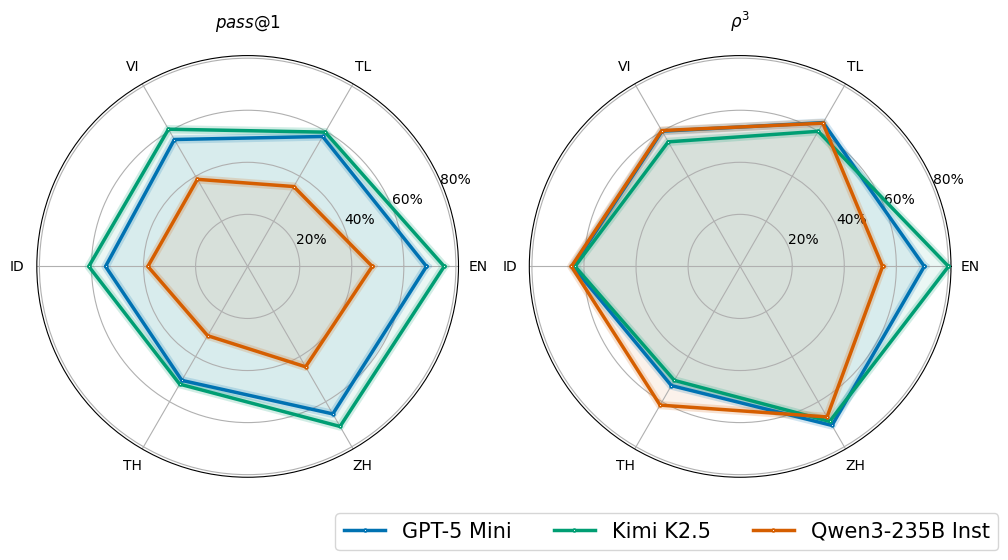

In [17]:
# Aggregate across domains so each (Metric, Model) has one value per language
radar_df = (
    df.groupby(["Metric", "Model"], as_index=False)[languages]
      .mean()
)
radar_df = radar_df.loc[
    (radar_df["Model"] != "qwen3.6-35b-a3b") & (~radar_df["Metric"].isin(["pass^2", "pass^3"]))
, :]

metrics = radar_df["Metric"].unique()
n_metrics = len(metrics)

# More distinct color scheme (Okabe-Ito inspired)
radar_colors = {
    "gpt-5-mini": "#0072B2",           # blue
    "qwen3-235b-a22b-inst": "#D55E00", # vermillion
    "kimi-k2.5": "#009E73",            # bluish green
    "qwen3.6-35b-a3b": "#CC79A7",      # reddish purple
}

fig, axes = plt.subplots(
    1, n_metrics,
    subplot_kw=dict(polar=True),
    figsize=(5 * n_metrics, 6)
)

if n_metrics == 1:
    axes = [axes]

angles = np.linspace(0, 2 * np.pi, len(languages), endpoint=False).tolist()
angles += angles[:1]  # close the loop

for ax, metric in zip(axes, metrics):
    sub = radar_df[radar_df["Metric"] == metric]

    for _, row in sub.iterrows():
        model = row["Model"]
        values = row[languages].tolist()
        values += values[:1]

        c = radar_colors.get(model, "#333333")

        # Highlight layer (soft glow)
        ax.plot(
            angles, values,
            linewidth=6, color=c, alpha=0.18, zorder=2
        )

        # Main radar line
        ax.plot(
            angles, values,
            linewidth=2.5, color=c, label=model_map.get(model, model),
            marker="o", markersize=2,
            markerfacecolor="white", markeredgewidth=1.2,
            zorder=3
        )

        ax.fill(angles, values, alpha=0.08, color=c, zorder=1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([lang_map[lang] for lang in languages])
    ax.set_ylim(0, 0.81)
    metric_fmt = "$" + metric.replace("rho", "\\rho") + "$"
    ax.set_title(metric_fmt, pad=20)
    # ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_yticklabels(["", "20%", "", "40%", "", "60%", "", "80%"])
    ax.grid(True, alpha=1.0)

    # Highlight radial background lines at 0.2/0.4/0.6/0.8
    r_levels = [0.2, 0.4, 0.6, 0.8]
    ax.set_yticks(r_levels)
    ax.set_yticklabels(["20%", "40%", "60%", "80%"])

    # ax.grid(True, alpha=0.25)
    # theta_dense = np.linspace(0, 2 * np.pi, 720)
    # for r in r_levels:
    #     ax.plot(theta_dense, np.full_like(theta_dense, r),
    #             color="#666666", linewidth=1.6, alpha=0.55, zorder=0)

# Legend in one row below chart
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.33, 0.05), ncol=len(labels), fontsize=15)

    
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("perf_per_language.pdf", dpi=300, bbox_inches="tight")
plt.show()

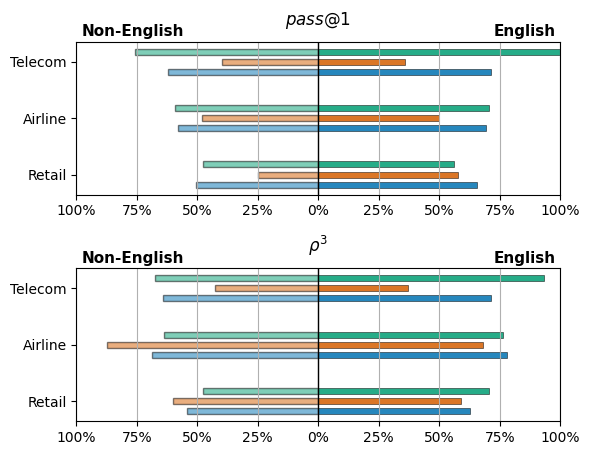

In [18]:
# Two-direction line plot:
#   right side  -> English
#   left side   -> Non-English average
#   each row    -> a domain

colors = {
    "gpt-5-mini": "#0072B2",           # blue
    "qwen3-235b-a22b-inst": "#D55E00", # vermillion
    "kimi-k2.5": "#009E73",            # bluish green
    "qwen3.6-35b-a3b": "#CC79A7",      # reddish purple
}

preferred_domain_order = ["Retail", "Airline", "Telecom"]
domain_order = [d for d in preferred_domain_order if d in domains]
domain_order += [d for d in domains if d not in domain_order]

plot_df = df.loc[
    (~df["Model"].isin(["qwen3.6-35b-a3b"])) & (~df["Metric"].isin(["pass^2", "pass^3"])),
    :
].copy()

models = plot_df["Model"].unique()
non_en_langs = [lang for lang in languages if lang != "English"]

# Shared x-limit for all subplots
non_en_series = plot_df[non_en_langs].mean(axis=1, skipna=True)
max_val = np.nanmax(np.r_[plot_df["English"].to_numpy(), non_en_series.to_numpy()])
xmax = min(1.0, max_val * 1.15)

fig, axes = plt.subplots(
    len(metrics), 1,
    figsize=(6, 2.5 * len(metrics)),
    # sharex=True,
    squeeze=False,
)

y_base = np.arange(len(domain_order))
offsets = np.linspace(-0.18, 0.18, len(models)) if len(models) > 1 else np.array([0.0])

for i, metric in enumerate(metrics):
    ax = axes[i, 0]

    for j, model in enumerate(models):
        sub = (
            plot_df[(plot_df["Metric"] == metric) & (plot_df["Model"] == model)]
            .set_index("Domain")
            .reindex(domain_order)
        )

        en_vals = sub["English"].to_numpy(dtype=float)
        non_en_vals = sub[non_en_langs].mean(axis=1, skipna=True).to_numpy(dtype=float)

        x_left = -non_en_vals
        x_right = en_vals
        y = y_base + offsets[j]

        bar_h = 0.32 / max(len(models), 1)
        y = y_base + offsets[j]

        # Left side: Non-English (negative for diverging bars)
        ax.barh(
            y, -non_en_vals,
            height=bar_h,
            color=colors[model],
            alpha=0.5,
            edgecolor="black",
            linewidth=1.0
        )

        # Right side: English
        ax.barh(
            y, en_vals,
            height=bar_h,
            color=colors[model],
            alpha=0.85,
            edgecolor="black",
            linewidth=0.4,
            label=model_map[model]
        )

    ax.axvline(0, color="black", lw=1)
    ax.set_xlim(-xmax, xmax)
    ax.set_yticks(y_base)
    ax.set_yticklabels(domain_order)
    ax.grid(axis="x", alpha=1.0)

    metric_fmt = "$" + metric.replace("rho", "\\rho") + "$"
    ax.set_title(metric_fmt, pad=12)
    ax.set_xticks([-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0])
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{abs(x):.0%}"))

    ax.text(-xmax * 0.98, len(domain_order) - 0.6, "Non-English", ha="left", va="bottom", fontsize=11, fontweight="bold")
    ax.text(xmax * 0.98, len(domain_order) - 0.6, "English", ha="right", va="bottom", fontsize=11, fontweight="bold")
    if ax.get_legend() is not None:
        ax.get_legend().set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
# fig.legend(uniq.values(), uniq.keys(), loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(uniq), fontsize=13)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("en-vs-ml.pdf", dpi=300)
plt.show()


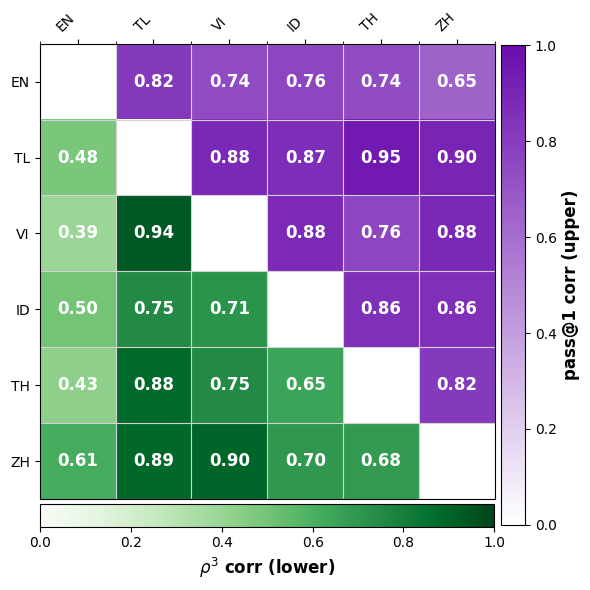

In [19]:
from matplotlib.colors import LinearSegmentedColormap

pass_corr = plot_df.loc[plot_df["Metric"] == "pass@1", languages].corr()
rho_corr = plot_df.loc[plot_df["Metric"] == "rho^3", languages].corr()

n = len(languages)
labels = [lang_map.get(lang, lang) for lang in languages]

pass_mat = pass_corr.to_numpy().copy()
rho_mat = rho_corr.to_numpy().copy()

# Remove trace (diagonal) -> set to null
np.fill_diagonal(pass_mat, np.nan)
np.fill_diagonal(rho_mat, np.nan)

upper = np.where(np.triu(np.ones((n, n), dtype=bool), k=1), pass_mat, np.nan)
lower = np.where(np.tril(np.ones((n, n), dtype=bool), k=-1), rho_mat, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))

# Colormaps with NaN shown as background color
bg = ax.get_facecolor()
purple_cmap = LinearSegmentedColormap.from_list("white_purple", ["#ffffff", "#6a0dad"])

green_cmap = plt.cm.Greens.copy()

# Value range 0..1
im_upper = ax.imshow(np.ma.masked_invalid(upper), cmap=purple_cmap, vmin=0, vmax=1)
im_lower = ax.imshow(np.ma.masked_invalid(lower), cmap=green_cmap, vmin=0, vmax=1)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# Bigger values in boxes; skip diagonal
for i in range(n):
    for j in range(n):
        if i < j:
            v = pass_corr.iat[i, j]
        elif i > j:
            v = rho_corr.iat[i, j]
        else:
            continue
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=12, color="white", fontweight="bold")

# Title removed
cbar1 = fig.colorbar(im_upper, ax=ax, fraction=0.039, pad=-0.2)
cbar1.set_label("pass@1 corr (upper)", fontsize=12, fontweight="bold")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Move cbar1 a bit upward
pos = cbar1.ax.get_position()
cbar1.ax.set_position([pos.x0, pos.y0, pos.width, pos.height])

cbar2 = fig.colorbar(im_lower, ax=ax, orientation="horizontal", fraction=0.047, pad=0.01)
cbar2.set_label("$\\rho^3$ corr (lower)", fontsize=12, fontweight="bold")
cbar2.ax.xaxis.set_label_position("bottom")
cbar2.ax.xaxis.set_ticks_position("bottom")

ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)

plt.tight_layout()
plt.savefig("corr_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()